In [7]:
import pandas as pd

print("Pandas version:", pd.__version__)
print("Python environment is working!")


Pandas version: 3.0.6
Python environment is working!


In [8]:
import pandas as pd

file_path = "../data/raw/online_retail_II.xlsx"

excel_file = pd.ExcelFile(file_path)

excel_file.sheet_names

df_2009 = pd.read_excel(
    file_path,
    sheet_name="Year 2009-2010"
)

df_2010 = pd.read_excel(
    file_path,
    sheet_name="Year 2010-2011"
)

df = pd.concat(
    [df_2009, df_2010],
    ignore_index=True
)

df.head()
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())
df.info()

missing_values = df.isna().sum()

missing_valuesmissing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2)
})

missing_summary = missing_summary.sort_values(
    "missing_percent",
    ascending=False
)

missing_summary
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2)
})

missing_summary = missing_summary.sort_values(
    by="missing_percent",
    ascending=False
)

print("Missing Value Summary:")
display(missing_summary)

missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2)
})

missing_summary = missing_summary.sort_values(
    by="missing_percent",
    ascending=False
)

display(missing_summary)
missing_summary = pd.DataFrame(...)




Number of rows: 1067371
Number of columns: 8

Column names:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']
<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 65.1+ MB


NameError: name 'missing_summary' is not defined

In [11]:
print(df.isna().sum())
print((df.isna().mean() * 100).round(2))
print("Duplicate rows:", df.duplicated().sum())


Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64
Invoice         0.00
StockCode       0.00
Description     0.41
Quantity        0.00
InvoiceDate     0.00
Price           0.00
Customer ID    22.77
Country         0.00
dtype: float64
Duplicate rows: 34335


In [12]:
print(df.isna().sum())


Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64


In [13]:
missing_percent = (df.isna().mean() * 100).round(2)

print(missing_percent)


Invoice         0.00
StockCode       0.00
Description     0.41
Quantity        0.00
InvoiceDate     0.00
Price           0.00
Customer ID    22.77
Country         0.00
dtype: float64


In [14]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)


Duplicate rows: 34335


In [15]:
print("Quantity <= 0:", (df["Quantity"] <= 0).sum())
print("Price <= 0:", (df["Price"] <= 0).sum())


Quantity <= 0: 22950
Price <= 0: 6207


In [16]:
negative_quantity = df[df["Quantity"] < 0]

print("Negative quantity rows:", len(negative_quantity))

display(
    negative_quantity[
        ["Invoice", "StockCode", "Description",
         "Quantity", "InvoiceDate", "Price", "Customer ID"]
    ].head(20)
)


Negative quantity rows: 22950


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0
183,C489449,21871,SAVE THE PLANET MUG,-12,2009-12-01 10:33:00,1.25,16321.0
184,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,2009-12-01 10:33:00,1.25,16321.0
185,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,2009-12-01 10:33:00,0.85,16321.0
186,C489449,22090,PAPER BUNTING RETRO SPOTS,-12,2009-12-01 10:33:00,2.95,16321.0
196,C489459,90200A,PURPLE SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592.0


In [17]:
print(
    "Negative-quantity rows with C invoices:",
    negative_quantity["Invoice"].astype(str).str.startswith("C").sum()
)


Negative-quantity rows with C invoices: 19493


In [18]:
non_positive_price = df[df["Price"] <= 0]

print("Non-positive price rows:", len(non_positive_price))

display(
    non_positive_price[
        ["Invoice", "StockCode", "Description",
         "Quantity", "InvoiceDate", "Price", "Customer ID"]
    ].head(20)
)


Non-positive price rows: 6207


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.0,NaN
283,489463,71477,short,-240,2009-12-01 10:52:00,0.0,NaN
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.0,NaN
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.0,NaN
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.0,NaN
3161,489659,21350,NaN,230,2009-12-01 17:39:00,0.0,NaN
3162,489660,35956,lost,-1043,2009-12-01 17:43:00,0.0,NaN
3168,489663,35605A,damages,-117,2009-12-01 18:02:00,0.0,NaN
3731,489781,84292,NaN,17,2009-12-02 11:45:00,0.0,NaN
4296,489806,18010,NaN,-770,2009-12-02 12:42:00,0.0,NaN


In [19]:
print("Price = 0:", (df["Price"] == 0).sum())
print("Price < 0:", (df["Price"] < 0).sum())


Price = 0: 6202
Price < 0: 5


In [20]:
negative_quantity = df[df["Quantity"] < 0]

print("Negative quantity rows:", len(negative_quantity))

print(
    "Negative quantity rows with C invoices:",
    negative_quantity["Invoice"].astype(str).str.startswith("C").sum()
)

print(
    "Negative quantity rows without C invoices:",
    (~negative_quantity["Invoice"].astype(str).str.startswith("C")).sum()
)


Negative quantity rows: 22950
Negative quantity rows with C invoices: 19493
Negative quantity rows without C invoices: 3457


In [21]:
zero_price = df[df["Price"] == 0]

print("Zero-price rows:", len(zero_price))

display(
    zero_price["Description"]
    .value_counts(dropna=False)
    .head(20)
)


Zero-price rows: 6202


Description
NaN                              4382
check                             162
?                                  92
damages                            84
damaged                            81
found                              28
missing                            27
sold as set on dotcom              20
Damaged                            17
adjustment                         16
OWL DOORSTOP                       15
POLYESTER FILLER PAD 45x45cm       12
dotcom                             12
amazon                             11
POLYESTER FILLER PAD 40x40cm       10
IVORY KITCHEN SCALES               10
FRENCH BLUE METAL DOOR SIGN 1      10
smashed                             9
Found                               9
PICNIC BASKET WICKER LARGE          9
Name: count, dtype: int64

In [22]:
df_clean = df.copy()

print("Original rows:", len(df))
print("Working rows:", len(df_clean))


Original rows: 1067371
Working rows: 1067371


In [23]:
duplicates = df_clean[df_clean.duplicated(keep=False)]

print("Rows involved in exact duplicates:", len(duplicates))

display(duplicates.head(20))


Rows involved in exact duplicates: 67242


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
362,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
363,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
365,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
367,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,16329.0,United Kingdom
368,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329.0,United Kingdom
371,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
379,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,16329.0,United Kingdom
383,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329.0,United Kingdom
384,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,16329.0,United Kingdom
385,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom


In [24]:
df_no_duplicates = df_clean.drop_duplicates()

print("Original rows:", len(df_clean))
print("Rows after removing exact duplicates:", len(df_no_duplicates))
print("Rows removed:", len(df_clean) - len(df_no_duplicates))


Original rows: 1067371
Rows after removing exact duplicates: 1033036
Rows removed: 34335


In [25]:
print("Remaining duplicate rows:", df_no_duplicates.duplicated().sum())


Remaining duplicate rows: 0


In [26]:
# Check whether missing descriptions can be recovered from StockCode

missing_desc = df_no_duplicates[df_no_duplicates["Description"].isna()]

print("Missing descriptions:", len(missing_desc))
print("Unique StockCodes with missing descriptions:",
      missing_desc["StockCode"].nunique())


Missing descriptions: 4275
Unique StockCodes with missing descriptions: 2451


In [27]:
# How many missing-description products have a known description elsewhere?

known_descriptions = (
    df_no_duplicates
    .dropna(subset=["Description"])
    .groupby("StockCode")["Description"]
    .nunique()
)

recoverable = missing_desc["StockCode"].isin(
    known_descriptions[known_descriptions > 0].index
).sum()

print("Recoverable missing descriptions:", recoverable)


Recoverable missing descriptions: 3912


In [28]:
known_descriptions = (
    df_no_duplicates
    .dropna(subset=["Description"])
    .groupby("StockCode")["Description"]
    .nunique()
)

recoverable = missing_desc["StockCode"].isin(
    known_descriptions[known_descriptions > 0].index
).sum()

print("Recoverable missing descriptions:", recoverable)


Recoverable missing descriptions: 3912


In [29]:
# Create a StockCode -> Description lookup

description_lookup = (
    df_no_duplicates
    .dropna(subset=["Description"])
    .groupby("StockCode")["Description"]
    .first()
)

# Fill missing descriptions using StockCode
df_clean = df_no_duplicates.copy()

df_clean["Description"] = (
    df_clean["Description"]
    .fillna(df_clean["StockCode"].map(description_lookup))
)

print("Remaining missing descriptions:",
      df_clean["Description"].isna().sum())


Remaining missing descriptions: 363


In [30]:
unresolved_desc = df_clean[df_clean["Description"].isna()]

print("Unresolved descriptions:", len(unresolved_desc))
print("Unique StockCodes:", unresolved_desc["StockCode"].nunique())

display(
    unresolved_desc[
        ["Invoice", "StockCode", "Quantity",
         "InvoiceDate", "Price", "Customer ID", "Country"]
    ].head(20)
)


Unresolved descriptions: 363
Unique StockCodes: 355


,Invoice,StockCode,Quantity,InvoiceDate,Price,Customer ID,Country
470,489521,21646,-50,2009-12-01 11:44:00,0.0,NaN,United Kingdom
16186,490736,35983,-200,2009-12-07 17:13:00,0.0,NaN,United Kingdom
19313,490976,84571,-120,2009-12-08 16:42:00,0.0,NaN,United Kingdom
20975,491066,35949,-67,2009-12-09 12:17:00,0.0,NaN,United Kingdom
22854,491167,17013A,-45,2009-12-10 11:09:00,0.0,NaN,United Kingdom
23542,491206,84841,-54,2009-12-10 14:10:00,0.0,NaN,United Kingdom
32106,491975,72752C,-24,2009-12-14 18:44:00,0.0,NaN,United Kingdom
32109,491977,72755B,-23,2009-12-14 18:45:00,0.0,NaN,United Kingdom
32110,491976,72752D,-46,2009-12-14 18:45:00,0.0,NaN,United Kingdom
43528,493138,35751A,152,2009-12-22 11:32:00,0.0,NaN,United Kingdom


In [31]:
df_clean["Description"] = df_clean["Description"].fillna("Unknown")

print("Remaining missing descriptions:",
      df_clean["Description"].isna().sum())


Remaining missing descriptions: 0


In [32]:
negative_price = df_clean[df_clean["Price"] < 0]

print("Negative-price rows:", len(negative_price))

display(
    negative_price[
        ["Invoice", "StockCode", "Description",
         "Quantity", "InvoiceDate", "Price",
         "Customer ID", "Country"]
    ]
)


Negative-price rows: 5


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom
825444,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
825445,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


In [33]:
Negative-price rows: 5
Invoice	StockCode	Description	Quantity	InvoiceDate	Price	Customer ID	Country
179403	A506401	B	Adjust bad debt	1	2010-04-29 13:36:00	-53594.36	NaN	United Kingdom
276274	A516228	B	Adjust bad debt	1	2010-07-19 11:24:00	-44031.79	NaN	United Kingdom
403472	A528059	B	Adjust bad debt	1	2010-10-20 12:04:00	-38925.87	NaN	United Kingdom
825444	A563186	B	Adjust bad debt	1	2011-08-12 14:51:00	-11062.06	NaN	United Kingdom
825445	A563187	B	Adjust bad debt	1	2011-08-12 14:52:00	-11062.06	NaN	United Kingdom

SyntaxError: leading zeros in decimal integer literals are not permitted; use an 0o prefix for octal integers (1242830232.py, line 3)

In [34]:
missing_customer = df_clean["Customer ID"].isna()

print("Missing Customer IDs:", missing_customer.sum())
print(
    "Percentage:",
    round(missing_customer.mean() * 100, 2),
    "%"
)


Missing Customer IDs: 235151
Percentage: 22.76 %


In [35]:
display(
    df_clean.loc[
        missing_customer,
        ["Invoice", "StockCode", "Description",
         "Quantity", "Price", "Country"]
    ].head(20)
)


,Invoice,StockCode,Description,Quantity,Price,Country
263,489464,21733,85123a mixed,-96,0.00,United Kingdom
283,489463,71477,short,-240,0.00,United Kingdom
284,489467,85123A,21733 mixed,-192,0.00,United Kingdom
470,489521,21646,Unknown,-50,0.00,United Kingdom
577,489525,85226C,BLUE PULL BACK RACING CAR,1,0.55,United Kingdom
578,489525,85227,SET/6 3D KIT CARDS FOR KIDS,1,0.85,United Kingdom
1055,489548,22271,FELTCRAFT DOLL ROSIE,1,2.95,United Kingdom
1056,489548,22254,FELT TOADSTOOL LARGE,12,1.25,United Kingdom
1057,489548,22273,FELTCRAFT DOLL MOLLY,3,2.95,United Kingdom
1058,489548,22195,LARGE HEART MEASURING SPOONS,1,1.65,United Kingdom


In [36]:
bad_debt = df_clean["Description"].eq("Adjust bad debt")

print("Bad-debt adjustment rows:", bad_debt.sum())

df_clean = df_clean[~bad_debt].copy()

print("Rows after removing bad-debt adjustments:", len(df_clean))


Bad-debt adjustment rows: 6
Rows after removing bad-debt adjustments: 1033030


In [37]:
print("Negative prices remaining:", (df_clean["Price"] < 0).sum())


Negative prices remaining: 0


In [38]:
missing_customer = df_clean["Customer ID"].isna()

print("Missing Customer IDs:", missing_customer.sum())
print("Percentage:", round(missing_customer.mean() * 100, 2), "%")


Missing Customer IDs: 235145
Percentage: 22.76 %


In [39]:
df_customer = df_clean.dropna(subset=["Customer ID"]).copy()

print("Rows available for customer analysis:", len(df_customer))
print("Rows excluded from customer analysis:", len(df_clean) - len(df_customer))


Rows available for customer analysis: 797885
Rows excluded from customer analysis: 235145


In [40]:
print(df_clean["Customer ID"].describe())


count    797885.000000
mean      15313.062777
std        1696.466663
min       12346.000000
25%       13964.000000
50%       15228.000000
75%       16788.000000
max       18287.000000
Name: Customer ID, dtype: float64


In [41]:
print("Unique Customer IDs:",
      df_clean["Customer ID"].nunique())


Unique Customer IDs: 5942


In [42]:
print("FINAL DATA QUALITY CHECK")
print("=" * 40)

print("Rows:", len(df_clean))
print("Columns:", len(df_clean.columns))
print("Duplicate rows:", df_clean.duplicated().sum())
print("Missing descriptions:", df_clean["Description"].isna().sum())
print("Negative prices:", (df_clean["Price"] < 0).sum())
print("Zero prices:", (df_clean["Price"] == 0).sum())
print("Negative quantities:", (df_clean["Quantity"] < 0).sum())
print("Missing Customer IDs:", df_clean["Customer ID"].isna().sum())


FINAL DATA QUALITY CHECK
Rows: 1033030
Columns: 8
Duplicate rows: 0
Missing descriptions: 0
Negative prices: 0
Zero prices: 6014
Negative quantities: 22496
Missing Customer IDs: 235145


In [43]:
df_clean["Revenue"] = df_clean["Quantity"] * df_clean["Price"]

print(df_clean["Revenue"].describe())


count    1.033030e+06
mean     1.839554e+01
std      2.845114e+02
min     -1.684696e+05
25%      3.750000e+00
50%      9.920000e+00
75%      1.770000e+01
max      1.684696e+05
Name: Revenue, dtype: float64


In [44]:
sales = df_clean[df_clean["Quantity"] > 0]
returns = df_clean[df_clean["Quantity"] < 0]

print("Positive-quantity rows:", len(sales))
print("Negative-quantity rows:", len(returns))

print("Sales revenue:", sales["Revenue"].sum())
print("Return/cancellation revenue:", returns["Revenue"].sum())

print("Net revenue:", df_clean["Revenue"].sum())


Positive-quantity rows: 1010534
Negative-quantity rows: 22496
Sales revenue: 20465571.958
Return/cancellation revenue: -1462424.1800000002
Net revenue: 19003147.778


In [45]:
print("Zero-quantity rows:", (df_clean["Quantity"] == 0).sum())


Zero-quantity rows: 0


In [46]:
monthly_revenue = (
    df_clean
    .groupby(df_clean["InvoiceDate"].dt.to_period("M"))["Revenue"]
    .sum()
    .reset_index()
)

monthly_revenue["InvoiceDate"] = monthly_revenue["InvoiceDate"].astype(str)

monthly_revenue


,InvoiceDate,Revenue
0,2009-12,796648.500
1,2010-01,622479.502
2,2010-02,531265.366
3,2010-03,763247.241
4,2010-04,641521.052
5,2010-05,613270.720
6,2010-06,677073.870
7,2010-07,617365.480
8,2010-08,654774.390
9,2010-09,851105.961


In [47]:
top_products = (
    df_clean
    .groupby(["StockCode", "Description"])
    .agg(
        Revenue=("Revenue", "sum"),
        Quantity=("Quantity", "sum"),
        Transactions=("Invoice", "nunique")
    )
    .sort_values("Revenue", ascending=False)
    .head(20)
)

top_products


,,Revenue,Quantity,Transactions
StockCode,Description,,,
22423,REGENCY CAKESTAND 3 TIER,314045.02,25015,4262
DOT,DOTCOM POSTAGE,309844.10,2917,1425
85123A,WHITE HANGING HEART T-LIGHT HOLDER,248159.10,90510,5495
47566,PARTY BUNTING,147079.73,27963,2700
85099B,JUMBO BAG RED RETROSPOT,143834.41,76095,3320
84879,ASSORTED COLOUR BIRD ORNAMENT,128550.42,79579,2827
22086,PAPER CHAIN KIT 50'S CHRISTMAS,116298.59,34434,2036
POST,POSTAGE,110430.41,10011,2084
79321,CHILLI LIGHTS,79905.13,15652,1172


In [48]:
top_physical_products = (
    df_clean[
        ~df_clean["StockCode"].isin(["DOT", "POST"])
    ]
    .groupby(["StockCode", "Description"])["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_physical_products


,StockCode,Description,Revenue
0,22423,REGENCY CAKESTAND 3 TIER,314045.02
1,85123A,WHITE HANGING HEART T-LIGHT HOLDER,248159.10
2,47566,PARTY BUNTING,147079.73
3,85099B,JUMBO BAG RED RETROSPOT,143834.41
4,84879,ASSORTED COLOUR BIRD ORNAMENT,128550.42
5,22086,PAPER CHAIN KIT 50'S CHRISTMAS,116298.59
6,79321,CHILLI LIGHTS,79905.13
7,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,70969.95
8,85099F,JUMBO BAG STRAWBERRY,67473.53
9,23084,RABBIT NIGHT LIGHT,66661.63


In [49]:
country_revenue = (
    df_clean
    .groupby("Country")
    .agg(
        Revenue=("Revenue", "sum"),
        Quantity=("Quantity", "sum"),
        Transactions=("Invoice", "nunique"),
        Customers=("Customer ID", "nunique")
    )
    .sort_values("Revenue", ascending=False)
)

country_revenue.head(20)


,Revenue,Quantity,Transactions,Customers
Country,,,,
United Kingdom,1.613367e+07,8513700,49102,5410
EIRE,6.099538e+05,327431,806,5
Netherlands,5.483307e+05,381853,250,23
Germany,4.119592e+05,221816,1095,107
France,3.217334e+05,181572,746,95
Australia,1.664444e+05,103375,117,15
Switzerland,9.940306e+04,52256,123,22
Spain,9.101344e+04,44667,188,41
Sweden,8.777552e+04,87858,129,19


In [50]:
customer_revenue = (
    df_customer
    .groupby("Customer ID")
    .agg(
        Revenue=("Revenue", "sum"),
        Quantity=("Quantity", "sum"),
        Transactions=("Invoice", "nunique"),
        Products=("StockCode", "nunique"),
        Country=("Country", "first")
    )
    .sort_values("Revenue", ascending=False)
)

customer_revenue.head(20)


KeyError: "Label(s) ['Revenue'] do not exist"

In [51]:
df_customer = df_clean.dropna(subset=["Customer ID"]).copy()

print("Customer analysis rows:", len(df_customer))
print("Columns:", df_customer.columns.tolist())


Customer analysis rows: 797885
Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country', 'Revenue']


In [52]:
customer_revenue = (
    df_customer
    .groupby("Customer ID")
    .agg(
        Revenue=("Revenue", "sum"),
        Quantity=("Quantity", "sum"),
        Transactions=("Invoice", "nunique"),
        Products=("StockCode", "nunique"),
        Country=("Country", "first")
    )
    .sort_values("Revenue", ascending=False)
)

customer_revenue.head(20)


,Revenue,Quantity,Transactions,Products,Country
Customer ID,,,,,
18102.0,570380.61,180415,153,384,United Kingdom
14646.0,523342.07,365220,164,964,Netherlands
14156.0,296063.44,162245,202,1446,EIRE
14911.0,265757.91,141750,510,2557,EIRE
17450.0,231390.55,80838,61,148,United Kingdom
13694.0,190020.84,184534,164,902,United Kingdom
17511.0,168491.62,115449,85,678,United Kingdom
12415.0,143269.29,91315,33,498,Australia
16684.0,141502.25,101095,65,186,United Kingdom


In [53]:
print("Latest transaction date:",
      df_customer["InvoiceDate"].max())

print("Earliest transaction date:",
      df_customer["InvoiceDate"].min())


Latest transaction date: 2011-12-09 12:50:00
Earliest transaction date: 2009-12-01 07:45:00


In [54]:
reference_date = df_customer["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = (
    df_customer
    .groupby("Customer ID")
    .agg(
        Recency=("InvoiceDate",
                 lambda x: (reference_date - x.max()).days),
        Frequency=("Invoice", "nunique"),
        Monetary=("Revenue", "sum")
    )
)

rfm.head()


,Recency,Frequency,Monetary
Customer ID,,,
12346.0,326,17,-51.74
12347.0,2,8,4921.53
12348.0,75,5,2019.40
12349.0,19,5,4404.54
12350.0,310,1,334.40


In [55]:
rfm.describe()


,Recency,Frequency,Monetary
count,5942.000000,5942.000000,5942.000000
mean,202.908617,7.552339,2741.499712
std,211.857936,15.972262,13676.639629
min,1.000000,1.000000,-25111.090000
25%,25.000000,2.000000,321.065000
50%,96.000000,4.000000,822.010000
75%,381.000000,8.000000,2142.195000
max,739.000000,510.000000,570380.610000


In [56]:
# RFM scoring

rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    q=5,
    labels=[5, 4, 3, 2, 1],
    duplicates="drop"
)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5]
)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5]
)

rfm["R_Score"] = rfm["R_Score"].astype(int)
rfm["F_Score"] = rfm["F_Score"].astype(int)
rfm["M_Score"] = rfm["M_Score"].astype(int)

rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str)
    + rfm["F_Score"].astype(str)
    + rfm["M_Score"].astype(str)
)

rfm.head()


,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
Customer ID,,,,,,,
12346.0,326,17,-51.74,2,5,1,251
12347.0,2,8,4921.53,5,4,5,545
12348.0,75,5,2019.40,3,3,4,334
12349.0,19,5,4404.54,4,3,5,435
12350.0,310,1,334.40,2,1,2,212


In [57]:
print(rfm["R_Score"].value_counts().sort_index())
print()
print(rfm["F_Score"].value_counts().sort_index())
print()
print(rfm["M_Score"].value_counts().sort_index())


R_Score
1    1176
2    1199
3    1184
4    1191
5    1192
Name: count, dtype: int64

F_Score
1    1189
2    1188
3    1188
4    1188
5    1189
Name: count, dtype: int64

M_Score
1    1189
2    1188
3    1188
4    1188
5    1189
Name: count, dtype: int64


In [58]:
def rfm_segment(row):
    r, f, m = row["R_Score"], row["F_Score"], row["M_Score"]

    if r >= 4 and f >= 4 and m >= 4:
        return "High Value"
    elif r >= 4 and f >= 3:
        return "Loyal Active"
    elif r >= 4 and m >= 4:
        return "Recent High Value"
    elif r <= 2 and f >= 4:
        return "At Risk"
    elif r <= 2 and m >= 4:
        return "High Value At Risk"
    elif r <= 2 and f <= 2 and m <= 2:
        return "Inactive Low Value"
    elif r >= 3 and f <= 2:
        return "New / Occasional"
    else:
        return "Potential Loyalist"

rfm["Segment"] = rfm.apply(rfm_segment, axis=1)

rfm["Segment"].value_counts()


Segment
Potential Loyalist    1339
High Value            1303
Inactive Low Value    1302
New / Occasional       813
Loyal Active           621
At Risk                372
High Value At Risk     163
Recent High Value       29
Name: count, dtype: int64

In [59]:
segment_summary = (
    rfm
    .groupby("Segment")
    .agg(
        Customers=("Segment", "size"),
        Revenue=("Monetary", "sum"),
        Avg_Revenue=("Monetary", "mean"),
        Avg_Frequency=("Frequency", "mean"),
        Avg_Recency=("Recency", "mean")
    )
    .sort_values("Revenue", ascending=False)
)

segment_summary


,Customers,Revenue,Avg_Revenue,Avg_Frequency,Avg_Recency
Segment,,,,,
High Value,1303,1.144038e+07,8780.033849,20.886416,18.775902
Potential Loyalist,1339,2.314017e+06,1728.168242,6.014190,225.308439
At Risk,372,9.028338e+05,2426.972640,9.083333,354.107527
Loyal Active,621,6.235944e+05,1004.177795,4.476651,24.061192
New / Occasional,813,3.555666e+05,437.351319,1.504305,65.039360
High Value At Risk,163,3.498913e+05,2146.572583,3.134969,382.141104
Inactive Low Value,1302,2.370491e+05,182.065369,1.271889,473.913978
Recent High Value,29,6.665461e+04,2298.434828,2.034483,22.689655


In [60]:
customer_sorted = rfm.sort_values("Monetary", ascending=False).copy()

customer_sorted["Cumulative_Revenue"] = (
    customer_sorted["Monetary"].cumsum()
)

total_customer_revenue = customer_sorted["Monetary"].sum()

customer_sorted["Cumulative_Revenue_Pct"] = (
    customer_sorted["Cumulative_Revenue"]
    / total_customer_revenue
    * 100
)

n_customers = len(customer_sorted)

for pct in [1, 5, 10, 20, 50]:
    n = int(n_customers * pct / 100)
    revenue_share = (
        customer_sorted.iloc[n - 1]["Cumulative_Revenue_Pct"]
    )
    print(f"Top {pct}% of customers: {revenue_share:.2f}% of revenue")


Top 1% of customers: 31.26% of revenue
Top 5% of customers: 51.53% of revenue
Top 10% of customers: 63.69% of revenue
Top 20% of customers: 77.39% of revenue
Top 50% of customers: 94.15% of revenue


In [61]:
customer_frequency = (
    df_customer
    .groupby("Customer ID")["Invoice"]
    .nunique()
)

one_time = (customer_frequency == 1).sum()
repeat = (customer_frequency > 1).sum()

print("One-time customers:", one_time)
print("Repeat customers:", repeat)
print("Total customers:", len(customer_frequency))

print(
    "Repeat customer rate:",
    round(repeat / len(customer_frequency) * 100, 2),
    "%"
)


One-time customers: 1461
Repeat customers: 4481
Total customers: 5942
Repeat customer rate: 75.41 %


In [62]:
frequency_distribution = (
    customer_frequency
    .value_counts()
    .sort_index()
)

print(frequency_distribution.head(20))


Invoice
1     1461
2      875
3      622
4      482
5      390
6      281
7      254
8      177
9      158
10     138
11     107
12     103
13      91
14      93
15      60
16      53
17      51
18      51
19      36
20      42
Name: count, dtype: int64


In [63]:
print("Customers with 5+ orders:",
      (customer_frequency >= 5).sum())

print("Customers with 10+ orders:",
      (customer_frequency >= 10).sum())

print("Customers with 20+ orders:",
      (customer_frequency >= 20).sum())

print("Customers with 50+ orders:",
      (customer_frequency >= 50).sum())


Customers with 5+ orders: 2502
Customers with 10+ orders: 1242
Customers with 20+ orders: 459
Customers with 50+ orders: 85


In [64]:
order_summary = (
    df_clean
    .groupby("Invoice")
    .agg(
        Order_Revenue=("Revenue", "sum"),
        Items=("Quantity", "sum"),
        Unique_Products=("StockCode", "nunique"),
        Customer_ID=("Customer ID", "first"),
        Country=("Country", "first")
    )
)

print(order_summary.describe())


       Order_Revenue         Items  Unique_Products   Customer_ID
count   53622.000000  53622.000000     53622.000000  44876.000000
mean      354.390880    194.132502        19.048488  15262.748418
std      1579.090261   1229.259476        37.846085   1719.882638
min   -168469.600000 -87167.000000         1.000000  12346.000000
25%         0.000000      2.000000         1.000000  13777.000000
50%       192.330000     91.000000         9.000000  15159.000000
75%       394.845000    228.000000        22.000000  16754.000000
max    168469.600000  87167.000000      1110.000000  18287.000000


In [65]:
print("Total orders:", len(order_summary))
print("Median order value:",
      order_summary["Order_Revenue"].median())
print("Average order value:",
      order_summary["Order_Revenue"].mean())


Total orders: 53622
Median order value: 192.32999999999998
Average order value: 354.39088019842603


In [66]:
print("25th percentile:",
      order_summary["Order_Revenue"].quantile(0.25))

print("50th percentile:",
      order_summary["Order_Revenue"].quantile(0.50))

print("75th percentile:",
      order_summary["Order_Revenue"].quantile(0.75))

print("90th percentile:",
      order_summary["Order_Revenue"].quantile(0.90))

print("95th percentile:",
      order_summary["Order_Revenue"].quantile(0.95))

print("99th percentile:",
      order_summary["Order_Revenue"].quantile(0.99))


25th percentile: 0.0
50th percentile: 192.32999999999998
75th percentile: 394.845
90th percentile: 761.3000000000001
95th percentile: 1231.9299999999994
99th percentile: 3719.733900000002


In [67]:
print("Zero-value orders:",
      (order_summary["Order_Revenue"] == 0).sum())

print("Negative-value orders:",
      (order_summary["Order_Revenue"] < 0).sum())

print("Positive-value orders:",
      (order_summary["Order_Revenue"] > 0).sum())


Zero-value orders: 5254
Negative-value orders: 8291
Positive-value orders: 40077


In [68]:
positive_orders = order_summary[
    order_summary["Order_Revenue"] > 0
]

print("Positive-value orders:", len(positive_orders))
print("Positive-order median:",
      positive_orders["Order_Revenue"].median())
print("Positive-order average:",
      positive_orders["Order_Revenue"].mean())


Positive-value orders: 40077
Positive-order median: 302.21999999999997
Positive-order average: 510.6562856002196


In [69]:
print("Median items per positive order:",
      positive_orders["Items"].median())

print("Average items per positive order:",
      positive_orders["Items"].mean())

print("Median unique products per positive order:",
      positive_orders["Unique_Products"].median())

print("Average unique products per positive order:",
      positive_orders["Unique_Products"].mean())


Median items per positive order: 146.0
Average items per positive order: 280.1700726102253
Median unique products per positive order: 15.0
Average unique products per positive order: 24.88197719390174


In [70]:
monthly_seasonality = (
    df_clean
    .assign(Month=df_clean["InvoiceDate"].dt.month)
    .groupby("Month")
    .agg(
        Revenue=("Revenue", "sum"),
        Transactions=("Invoice", "nunique"),
        Quantity=("Quantity", "sum")
    )
    .sort_values("Revenue", ascending=False)
)

monthly_seasonality


,Revenue,Transactions,Quantity
Month,,,
11,2872843.002,7131,1407752
10,2149979.710,5601,1169406
12,1976091.170,5370,985318
9,1868702.643,4702,1025477
3,1445261.221,4350,839177
6,1367051.100,4228,727392
8,1347222.910,3611,856222
5,1335364.820,4580,742423
7,1297522.471,3943,690226


In [71]:
highest_month = monthly_seasonality["Revenue"].idxmax()
lowest_month = monthly_seasonality["Revenue"].idxmin()

highest_revenue = monthly_seasonality.loc[highest_month, "Revenue"]
lowest_revenue = monthly_seasonality.loc[lowest_month, "Revenue"]

print("Highest revenue month:", highest_month)
print("Highest revenue:", highest_revenue)

print("Lowest revenue month:", lowest_month)
print("Lowest revenue:", lowest_revenue)

print(
    "Highest vs lowest difference:",
    highest_revenue - lowest_revenue
)

print(
    "Highest month is",
    round(highest_revenue / lowest_revenue, 2),
    "x the lowest month"
)


Highest revenue month: 11
Highest revenue: 2872843.002
Lowest revenue month: 2
Lowest revenue: 1028291.776
Highest vs lowest difference: 1844551.2259999998
Highest month is 2.79 x the lowest month


In [72]:
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [73]:
df_clean

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.40
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.80
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.00
...,...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France,14.85


In [74]:
# Export cleaned dataset for SQL analysis
df_clean.to_csv("../data/processed/online_retail_clean.csv", index=False)

print("Cleaned dataset exported successfully.")
print(f"Rows exported: {len(df_clean):,}")

Cleaned dataset exported successfully.
Rows exported: 1,033,030


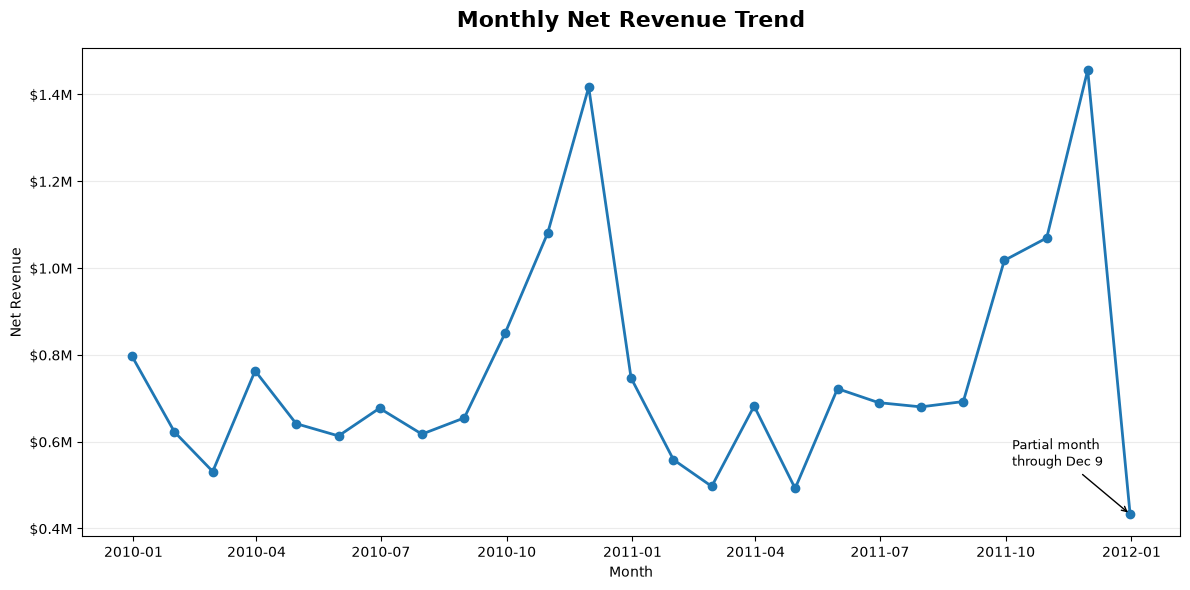

In [75]:
import matplotlib.pyplot as plt
import pandas as pd

# Prepare monthly revenue data
monthly_revenue = (
    df_clean
    .set_index("InvoiceDate")
    .resample("ME")["Revenue"]
    .sum()
)

# Create portfolio-quality visualization
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    monthly_revenue.index,
    monthly_revenue.values,
    marker="o",
    linewidth=2
)

ax.set_title(
    "Monthly Net Revenue Trend",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Month")
ax.set_ylabel("Net Revenue")

ax.grid(axis="y", alpha=0.25)

# Format revenue axis as dollars in millions
ax.yaxis.set_major_formatter(
    lambda x, pos: f"${x/1_000_000:.1f}M"
)

# Note that December 2011 is incomplete
ax.annotate(
    "Partial month\nthrough Dec 9",
    xy=(monthly_revenue.index[-1], monthly_revenue.iloc[-1]),
    xytext=(-85, 35),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->"),
    fontsize=9
)

plt.tight_layout()

plt.savefig(
    "../images/monthly_revenue_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

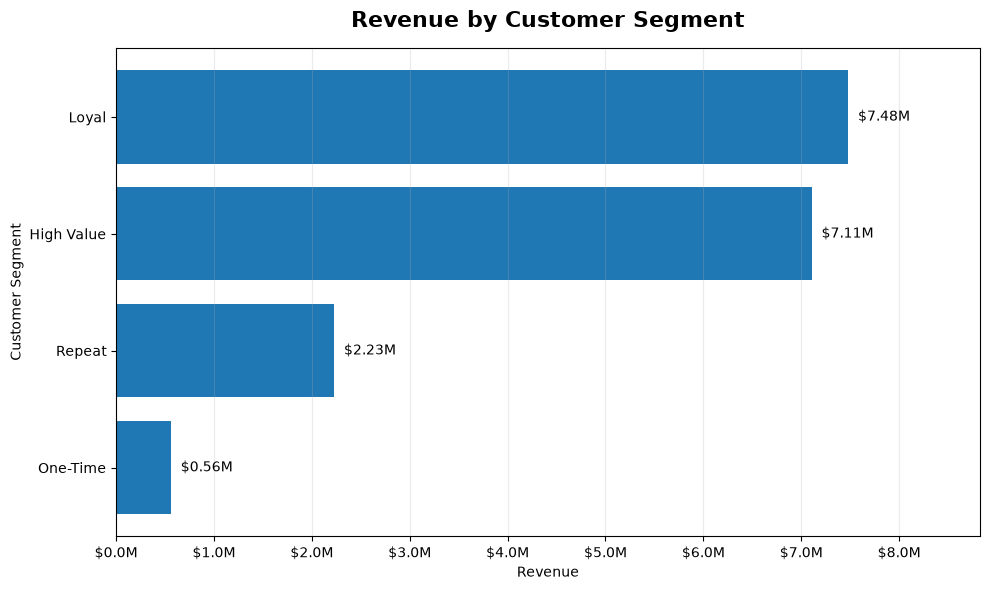

In [76]:
# Customer segment revenue visualization

segment_revenue = pd.DataFrame({
    "Segment": [
        "High Value",
        "Loyal",
        "Repeat",
        "One-Time"
    ],
    "Revenue": [
        7107060.19,
        7479698.14,
        2227773.37,
        560272.56
    ]
})

# Sort for a clean horizontal ranking
segment_revenue = segment_revenue.sort_values("Revenue")

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    segment_revenue["Segment"],
    segment_revenue["Revenue"]
)

ax.set_title(
    "Revenue by Customer Segment",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Revenue")
ax.set_ylabel("Customer Segment")

ax.xaxis.set_major_formatter(
    lambda x, pos: f"${x/1_000_000:.1f}M"
)

ax.grid(axis="x", alpha=0.25)

# Add revenue labels to bars
for bar in bars:
    value = bar.get_width()

    ax.text(
        value + 100000,
        bar.get_y() + bar.get_height() / 2,
        f"${value/1_000_000:.2f}M",
        va="center",
        fontsize=10
    )

ax.set_xlim(0, segment_revenue["Revenue"].max() * 1.18)

plt.tight_layout()

plt.savefig(
    "../images/customer_segment_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

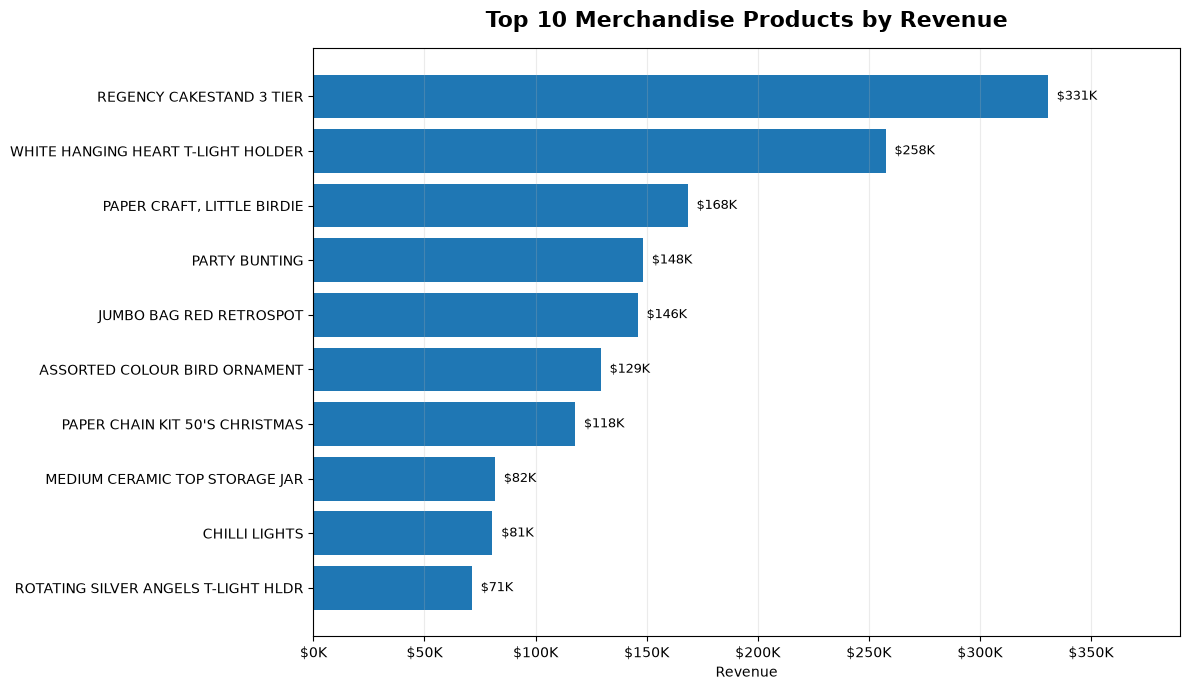

In [77]:
# Top merchandise products by revenue visualization

top_products = pd.DataFrame({
    "Product": [
        "REGENCY CAKESTAND 3 TIER",
        "WHITE HANGING HEART T-LIGHT HOLDER",
        "PAPER CRAFT, LITTLE BIRDIE",
        "PARTY BUNTING",
        "JUMBO BAG RED RETROSPOT",
        "ASSORTED COLOUR BIRD ORNAMENT",
        "PAPER CHAIN KIT 50'S CHRISTMAS",
        "MEDIUM CERAMIC TOP STORAGE JAR",
        "CHILLI LIGHTS",
        "ROTATING SILVER ANGELS T-LIGHT HLDR"
    ],
    "Revenue": [
        330590.32,
        257546.20,
        168469.60,
        148318.28,
        145961.83,
        129324.49,
        117760.29,
        81700.92,
        80540.88,
        71300.40
    ]
})

# Sort so highest-revenue product appears at the top
top_products = top_products.sort_values("Revenue")

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(
    top_products["Product"],
    top_products["Revenue"]
)

ax.set_title(
    "Top 10 Merchandise Products by Revenue",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Revenue")
ax.set_ylabel("")

ax.xaxis.set_major_formatter(
    lambda x, pos: f"${x/1000:.0f}K"
)

ax.grid(axis="x", alpha=0.25)

# Add revenue labels
for bar in bars:
    value = bar.get_width()

    ax.text(
        value + 4000,
        bar.get_y() + bar.get_height() / 2,
        f"${value/1000:.0f}K",
        va="center",
        fontsize=9
    )

ax.set_xlim(0, top_products["Revenue"].max() * 1.18)

plt.tight_layout()

plt.savefig(
    "../images/top_products_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()